In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
import sys
from tqdm.auto import tqdm
from time_series import create_time_series
sys.path.insert(0, os.path.abspath("../fsrs-optimizer/src/fsrs_optimizer/"))
import fsrs_optimizer
import numpy as np

tqdm.pandas()

In [20]:
# Review count: User id
# Median: 8798
# Most: 6810

USER_ID = 4321
df = pd.read_parquet(
    "../anki-revlogs-10k/revlogs", filters=[("user_id", "=", USER_ID), ("rating", "in", [1, 2, 3, 4])], columns=["card_id", "day_offset", "rating", "elapsed_days", "duration"] 
)
df.size

240225

In [21]:
df.describe()

,card_id,day_offset,rating,elapsed_days,duration
count,48045.000000,48045.000000,48045.000000,48045.000000,48045.000000
mean,8639.280404,2518.853263,3.010095,12.555146,28872.550859
std,3919.739762,282.733854,0.561920,75.416822,20737.413260
min,0.000000,0.000000,1.000000,-1.000000,0.000000
25%,5315.000000,2367.000000,3.000000,-1.000000,10460.000000
50%,9181.000000,2505.000000,3.000000,3.000000,22484.000000
75%,11747.000000,2735.000000,3.000000,7.000000,51252.000000
max,15124.000000,3049.000000,4.000000,2209.000000,60000.000000


In [22]:
df[df["card_id"] == 230]

,card_id,day_offset,rating,elapsed_days,duration
269,230,2226,3,-1,11081


In [23]:
df["prior_reviews"] = df.groupby("day_offset").cumcount()

In [24]:
print("creating time series")
df["delta_t"] = df["elapsed_days"]
df: pd.DataFrame = create_time_series(df)
print("training")
trainer = fsrs_optimizer.Trainer(df, df, fsrs_optimizer.DEFAULT_PARAMETER)
w = trainer.train()

creating time series
training


train:  47%|████▋     | 14049/29921 [00:00<00:00, 44619.83it/s]

iteration: 2816
w: [0.4165, 1.2446, 3.2564, 15.7769, 7.169, 0.5613, 1.4869, 0.001, 1.5711, 0.1, 1.0436, 1.9712, 0.0784, 0.3277, 2.3012, 0.222, 3.0304, 0.5377, 0.6841]
iteration: 5632
w: [0.4717, 1.2913, 3.314, 15.8375, 7.1353, 0.5965, 1.5104, 0.001, 1.6037, 0.0903, 1.0748, 1.9854, 0.065, 0.3424, 2.3181, 0.2095, 3.0805, 0.5517, 0.7042]
iteration: 8448
w: [0.5167, 1.3436, 3.3644, 15.8929, 7.0929, 0.6456, 1.5272, 0.0018, 1.6478, 0.0595, 1.1174, 1.9837, 0.0683, 0.3409, 2.319, 0.2224, 3.1244, 0.5575, 0.7127]
iteration: 11264
w: [0.5331, 1.3907, 3.4046, 15.9309, 7.0667, 0.6786, 1.557, 0.001, 1.6766, 0.0398, 1.1437, 2.0005, 0.0537, 0.3557, 2.3338, 0.2081, 3.1587, 0.588, 0.7437]
iteration: 14080
w: [0.541, 1.4246, 3.4382, 15.9611, 7.0432, 0.7068, 1.5858, 0.001, 1.7048, 0.0198, 1.1701, 1.9977, 0.0591, 0.3518, 2.3378, 0.2002, 3.192, 0.5791, 0.7401]


train: 100%|██████████| 29921/29921 [00:00<00:00, 53366.86it/s]


iteration: 16896
w: [0.5469, 1.4607, 3.4625, 16.0001, 7.0313, 0.721, 1.5986, 0.001, 1.7188, 0.0107, 1.1827, 1.9937, 0.0656, 0.3482, 2.3398, 0.188, 3.2027, 0.5716, 0.7334]
iteration: 19712
w: [0.5521, 1.4768, 3.4746, 16.0231, 7.025, 0.7284, 1.6135, 0.001, 1.7266, 0.0072, 1.1894, 1.9867, 0.074, 0.3417, 2.3357, 0.1807, 3.2079, 0.5668, 0.7269]
iteration: 22528
w: [0.556, 1.493, 3.487, 16.0368, 7.0197, 0.7334, 1.6162, 0.001, 1.7324, 0.0042, 1.1949, 1.9864, 0.0749, 0.3413, 2.3368, 0.1832, 3.214, 0.5716, 0.7291]
iteration: 25344
w: [0.5591, 1.4999, 3.4921, 16.0433, 7.0176, 0.7354, 1.618, 0.001, 1.7346, 0.004, 1.197, 1.9885, 0.073, 0.3434, 2.3393, 0.182, 3.2174, 0.5746, 0.7324]
iteration: 28160
w: [0.5597, 1.5024, 3.4938, 16.0455, 7.0171, 0.736, 1.6184, 0.001, 1.7352, 0.0039, 1.1975, 1.9893, 0.0723, 0.344, 2.3401, 0.182, 3.2186, 0.5751, 0.7332]


In [25]:
import math

DECAY = -0.5
FACTOR = 0.9 ** (1 / DECAY) - 1

def power_forgetting_curve(t, s):
    return (1 + FACTOR * t / s) ** DECAY

def stability_after_success(s, r, d, rating):
    hard_penalty = w[15] if rating == 2 else 1
    easy_bonus = w[16] if rating == 4 else 1
    return max(
        0.01,
        s * (
            1
            + math.exp(w[8])
            * (11 - d)
            * (s ** -w[9])
            * (math.exp((1 - r) * w[10]) - 1)
            * hard_penalty
            * easy_bonus
        )
    )

def stability_after_failure(s, r, d):
    return max(
        0.01,
        min(
            w[11]
            * (d ** -w[12])
            * ((s + 1) ** w[13] - 1)
            * math.exp((1 - r) * w[14]),
            s / math.exp(w[17] * w[18])
        )
    )

def stability_short_term(s, init_rating=None):
    if init_rating is not None:
        rating_offset = fsrs_optimizer.DEFAULT_FIRST_RATING_OFFSETS[init_rating - 1]
        session_len = fsrs_optimizer.DEFAULT_FIRST_SESSION_LENS[init_rating - 1]
    else:
        rating_offset = fsrs_optimizer.DEFAULT_FORGET_RATING_OFFSET
        session_len = fsrs_optimizer.DEFAULT_FORGET_SESSION_LEN
    
    new_s = s * math.exp(
        w[17] * (rating_offset + session_len * w[18])
    )
    return new_s

def init_d(rating):
    return w[4] - math.exp(w[5] * (rating - 1)) + 1

def init_d_with_short_term(rating):
    rating_offset = fsrs_optimizer.DEFAULT_FIRST_RATING_OFFSETS[rating - 1]
    new_d = init_d(rating) - w[6] * rating_offset
    return max(1, min(new_d, 10))

def linear_damping(delta_d, old_d):
    return delta_d * (10 - old_d) / 9

def mean_reversion(init, current):
    return w[7] * init + (1 - w[7]) * current

def next_d(d, rating):
    delta_d = -w[6] * (rating - 3)
    new_d = d + linear_damping(delta_d, d)
    new_d = mean_reversion(init_d(4), new_d)
    return max(1, min(new_d, 10))


In [26]:
def memory_state(df):
    t_history = [int(t) for t in df["t_history"].split(",")]
    r_history = [int(r) for r in df["r_history"].split(",")]
    difficulty = None
    stability = None
    retrievability = 1e-10
    for delta_t, rating in zip(t_history, r_history):
        if stability is None:  # New card
            difficulty = init_d_with_short_term(rating)
            stability = stability_short_term(w[rating - 1], init_rating=rating)
        else:
            retrievability = power_forgetting_curve(delta_t, stability)
            if rating > 1:
                stability = stability_after_success(
                    stability, retrievability, difficulty, rating
                )
            else:
                stability = stability_after_failure(stability, retrievability, difficulty)
                stability = stability_short_term(stability)
            difficulty = next_d(difficulty, rating)
            if rating == 1:
                difficulty -= (w[6] * fsrs_optimizer.DEFAULT_FORGET_RATING_OFFSET)
                difficulty = min(max(difficulty, 1), 10)

    return stability, difficulty, retrievability


df["s"], df["d"], df["r"] = zip(*df.progress_apply(memory_state, axis=1))

100%|██████████| 29921/29921 [00:00<00:00, 96822.07it/s] 


In [27]:
df["loss"] = df.apply(lambda df: (df["y"] - df["r"]) ** 2, axis=1)
df["duration"] = (df["duration"] / 1000).round(0)

Average Very Young cards per day 125.6


<Figure size 640x480 with 0 Axes>

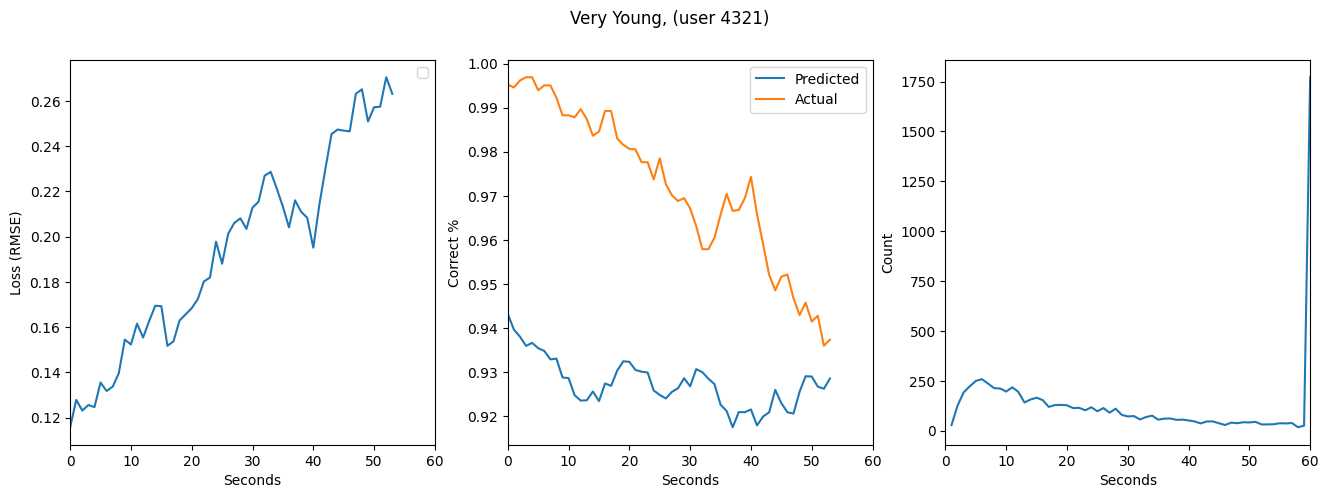

Average Young cards per day 275.75409836065575


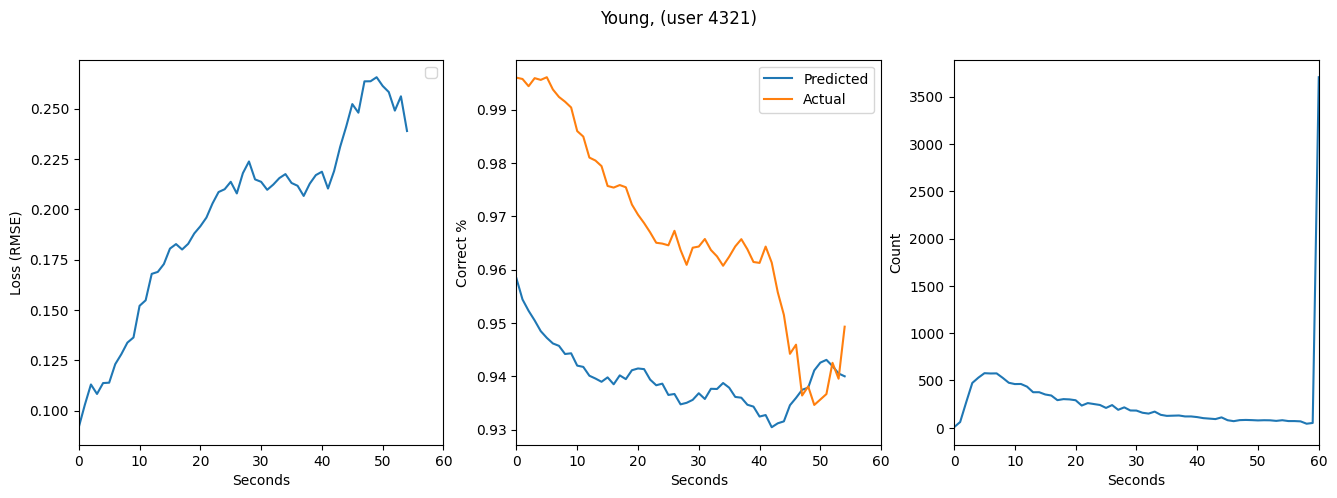

Average Mature cards per day 34.083333333333336


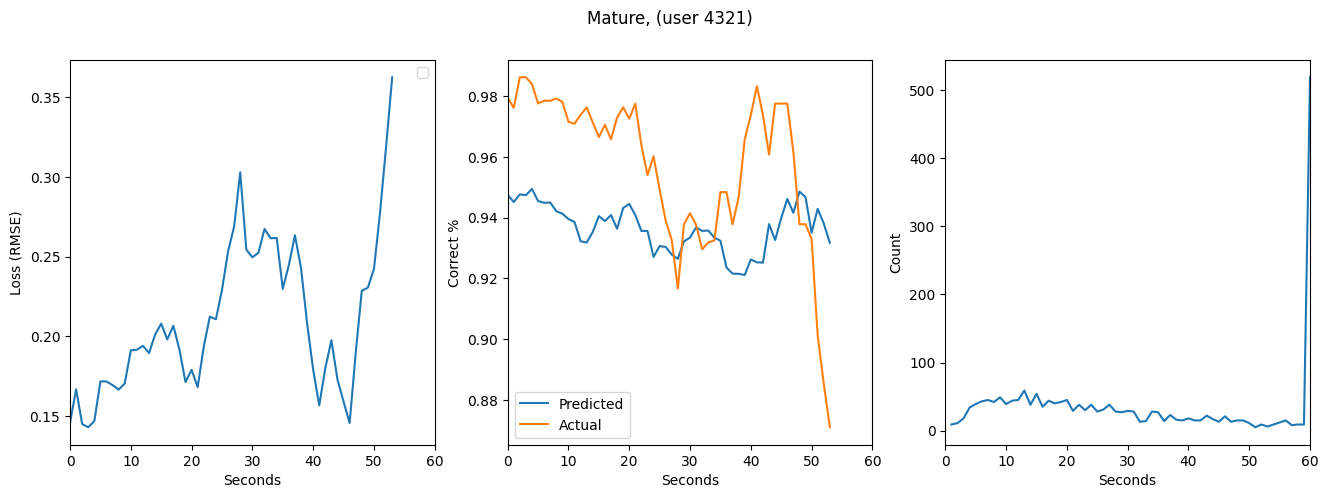

Average All cards per day 309.27868852459017


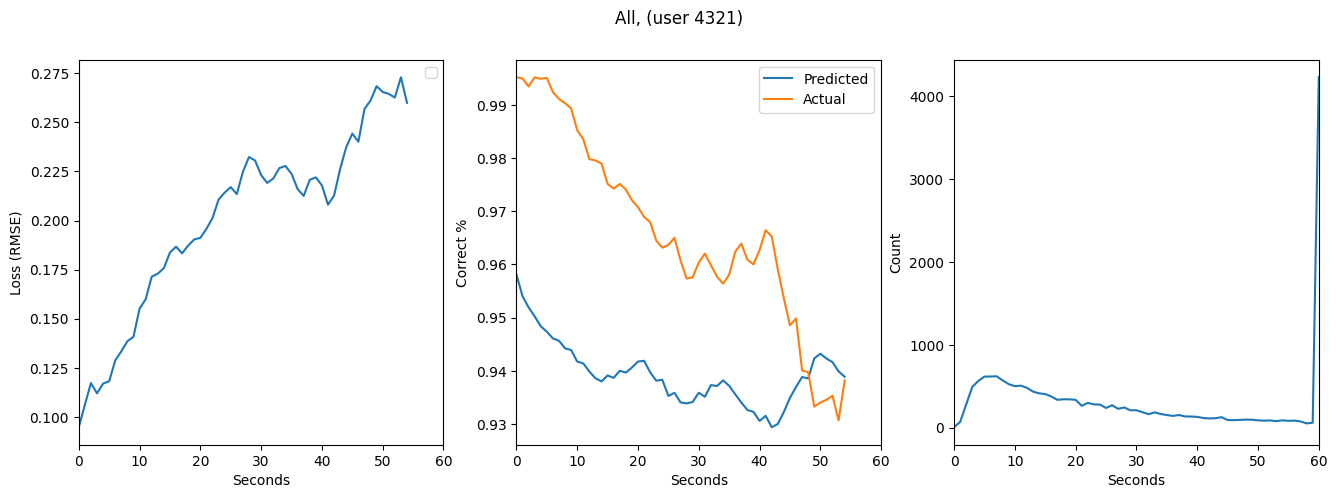

In [28]:
plt.clf()
categories = [
    #("Learn", -1, 1), 
    ("Very Young", 0, 4), 
    ("Young", 0, 21), 
    ("Mature", 21, 1e20),
    ("All", -1, 1e20)
]

# https://stackoverflow.com/a/54628145/24162642
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

for name, lower, upper in categories:
    df_filtered = df[(df["elapsed_days"] > lower) & (df["elapsed_days"] <= upper) & (df["r"] > 1e-9)].groupby("duration")

    print(f"Average {name} cards per day {df_filtered['card_id'].count().mean()}")
    loss = df_filtered["loss"].mean() ** 0.5
    loss = moving_average(loss, 7)

    fig = plt.figure(figsize=(16, 5))
    fig.suptitle(f"{name}, (user {USER_ID})")
    ax1 = fig.add_subplot(131)
    xlim = 60

    ax1.set_xlabel('Seconds')
    ax1.set_ylabel('Loss (RMSE)')
    ax1.plot(loss)
    ax1.legend()
    ax1.set_xlim(0, xlim)


    ax2 = fig.add_subplot(132)

    ax2.plot(moving_average(df_filtered["r"].mean(), 7), label="Predicted")
    ax2.plot(moving_average(df_filtered["y"].mean(), 7), label="Actual")
    ax2.set_xlabel('Seconds')
    ax2.set_ylabel('Correct %')
    ax2.set_xlim(0, xlim)
    ax2.legend()

    ax3 = fig.add_subplot(133)

    ax3.plot(df_filtered["r"].count())
    ax3.set_xlabel('Seconds')
    ax3.set_ylabel('Count') # Number of days that the user had that many reviews or more
    ax3.set_xlim(0, xlim)

    plt.show()


In [29]:
df_filtered = df[(df["elapsed_days"] > 0) & (df["r"] > 0.7)]
df_filtered.sort_values("elapsed_days", inplace=True)

/tmp/ipykernel_10728/3107958746.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.sort_values("elapsed_days", inplace=True)


In [30]:
df_filtered = df_filtered[df_filtered["rating"] == 3]

/home/luc/Programming/forks/fatigue-graph/.venv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


rating
3.0    25.83907
Name: duration, dtype: float64

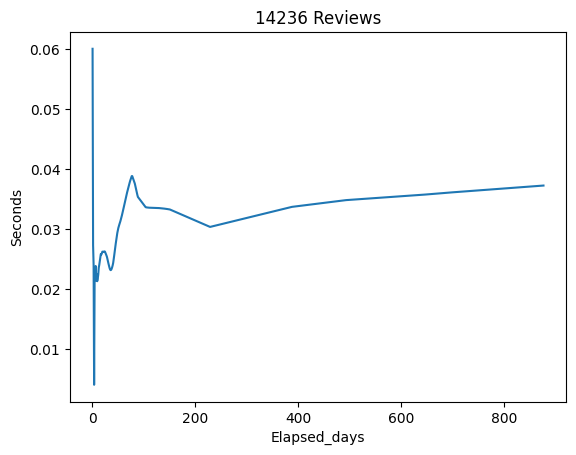

In [31]:
from utils import moving_average

x = df_filtered["elapsed_days"]
y = df_filtered["duration"] / 1000

plt.plot(*moving_average(x, y))
plt.xlabel("Elapsed_days")
plt.ylabel("Seconds")
plt.title(f"{len(df_filtered)} Reviews")

#plt.xlim((0.7, 0.99))

df_filtered.groupby("rating")["duration"].mean()

np.float64(39.75758249628686)

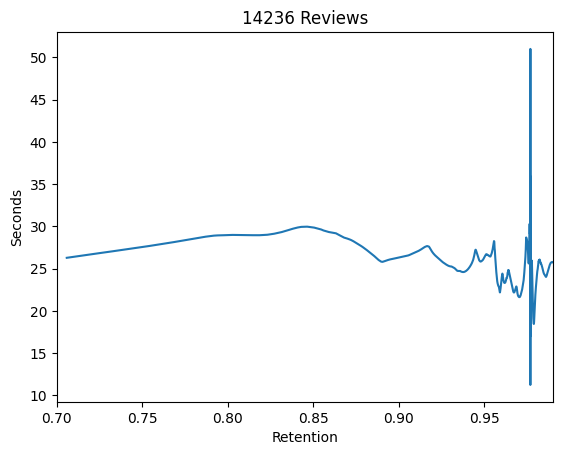

In [32]:
x = df_filtered["r"]
y = df_filtered["duration"]

x, y = moving_average(x, y)

plt.plot(x, y)
plt.xlabel("Retention")
plt.ylabel("Seconds")
plt.title(f"{len(df_filtered)} Reviews")

plt.xlim((0.7, 0.99))

max(y) - min(y)

np.float64(17.689206553631916)

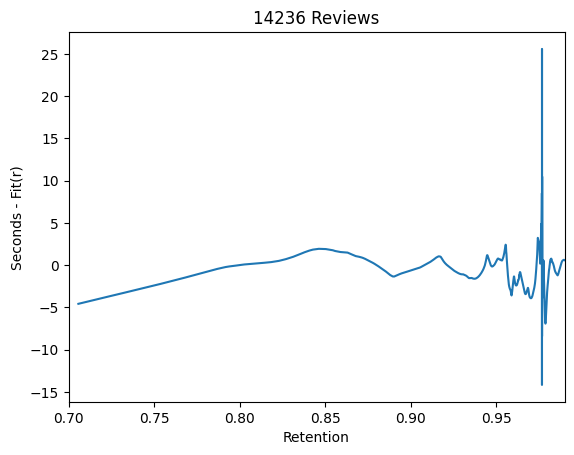

In [33]:
x = df_filtered["r"]
c = np.polyfit(df_filtered["r"], df_filtered["duration"], 1)
y = df_filtered["duration"] - np.polyval(c, df_filtered["r"])

plt.plot(*moving_average(x, y))
plt.xlabel("Retention")
plt.ylabel("Seconds - Fit(r)")
plt.title(f"{len(df_filtered)} Reviews")

plt.xlim((0.7, 0.99))
abs(y).mean()

np.float64(17.708033781465076)

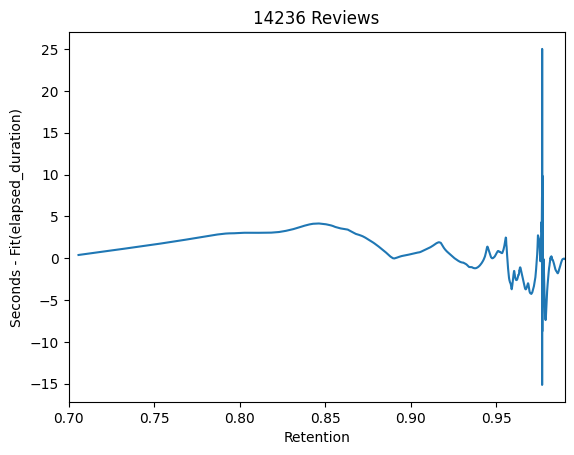

In [34]:
x = df_filtered["r"]
c1 = np.polyfit(df_filtered["elapsed_days"], df_filtered["duration"], 1)
y = df_filtered["duration"] - np.polyval(c1, df_filtered["elapsed_days"])

plt.plot(*moving_average(x, y))
plt.xlabel("Retention")
plt.ylabel("Seconds - Fit(elapsed_duration)")
plt.title(f"{len(df_filtered)} Reviews")

plt.xlim((0.7, 0.99))
abs(y).mean()

np.float64(3.1690726720558366)

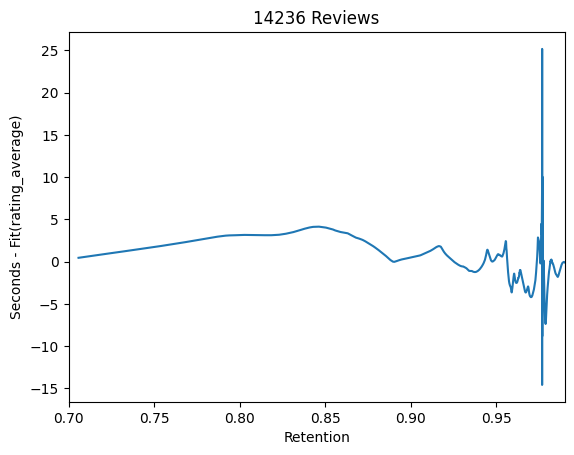

In [35]:
groups = df_filtered.groupby("rating")["duration"].mean()

x = df_filtered["r"]
y = df_filtered["duration"] - df_filtered["rating"].map(groups)

x, y = moving_average(x, y)

plt.plot(x, y)
plt.xlabel("Retention")
plt.ylabel("Seconds - Fit(rating_average)")
plt.title(f"{len(df_filtered)} Reviews")

plt.xlim((0.7, 0.99))
abs(y).mean()

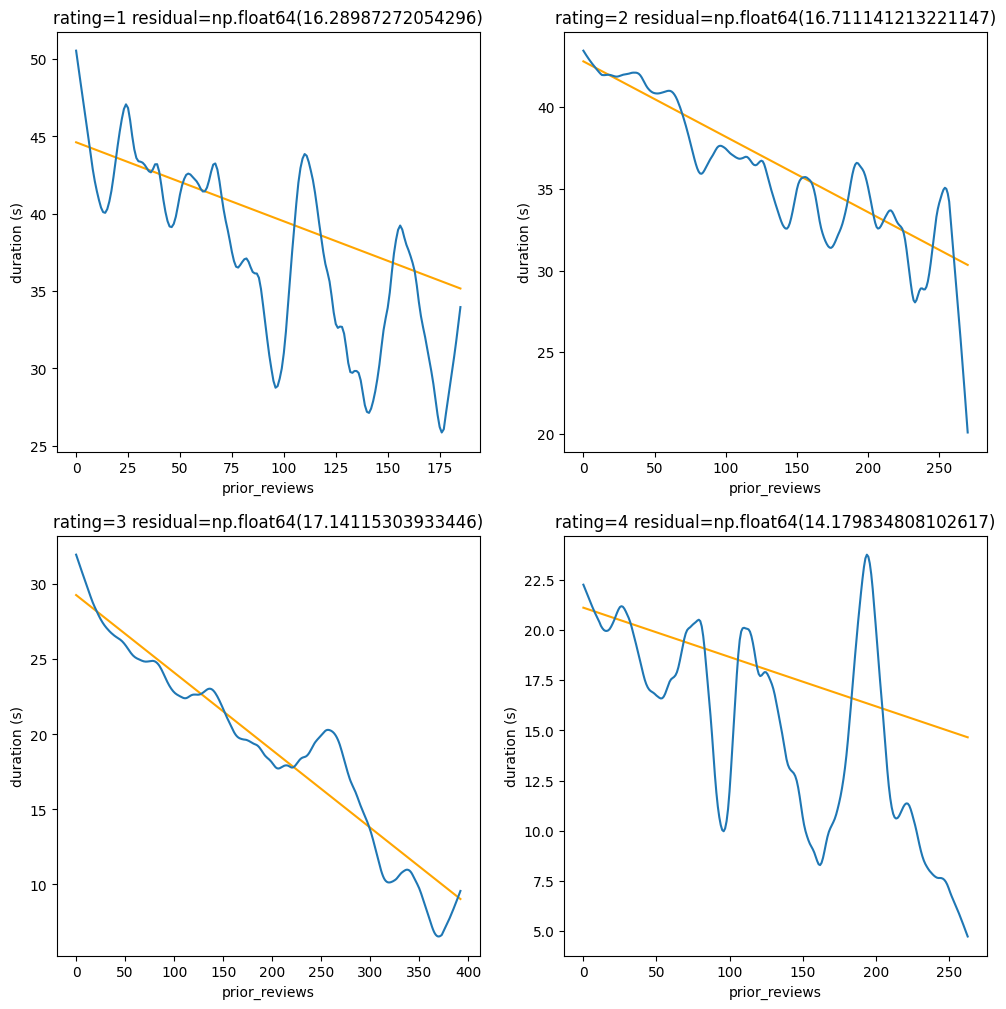

In [37]:
df["prior_reviews"] = df.groupby("day_offset").cumcount()
end = len(df.groupby("prior_reviews"))
def plot(df, axes, label):
    x = df["prior_reviews"]
    y = df["duration"]

    groups = df.groupby("prior_reviews")["duration"].mean()
    end = len(groups)

    c = np.polyfit(x, y, 1)
    axes.plot(np.arange(0, end), np.polyval(c, np.arange(0, end)), color="orange")
    axes.plot(*moving_average(np.arange(0, end), groups))

    residual = abs(y - np.polyval(c, x)).mean()
    axes.set_title(f"{label} {residual=}")
    axes.set_xlabel("prior_reviews")
    axes.set_ylabel("duration (s)")

fig = plt.figure(figsize=(12, 12))
for rating in range(1, 5):
    plot(df[df["rating"] == rating], fig.add_subplot(2, 2, rating), f"{rating=}")